Starting indefinite capture... Close window to stop.


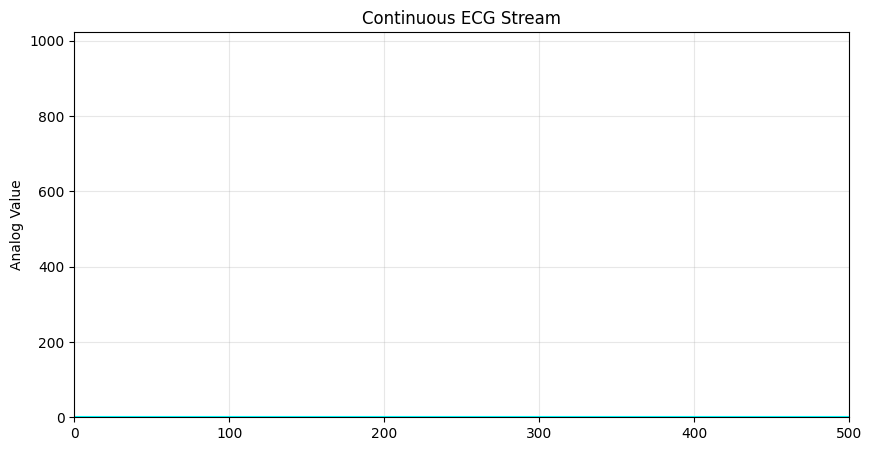

Serial Closed.


In [3]:
import serial
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from collections import deque
import numpy as np

# Configuration - Match your Arduino baud rate!
PORT = '/dev/ttyUSB0' 
BAUD = 115200  
WINDOW_SIZE = 500  # Number of points to show on screen at once

# Setup Serial
try:
    ser = serial.Serial(PORT, BAUD, timeout=0.1)
    ser.reset_input_buffer()
except Exception as e:
    print(f"Error: {e}")
    exit()

# Data buffers
data_buffer = deque([0] * WINDOW_SIZE, maxlen=WINDOW_SIZE)

# Setup Plot
fig, ax = plt.subplots(figsize=(10, 5))
line, = ax.plot([], [], color='cyan', lw=1.5)
ax.set_ylim(0, 1023) # Full 10-bit range
ax.set_xlim(0, WINDOW_SIZE)
ax.grid(True, alpha=0.3)
ax.set_title("Continuous ECG Stream")
ax.set_ylabel("Analog Value")

def update(frame):
    # Read all available data from the serial buffer to keep up with high sample rates
    while ser.in_waiting > 0:
        raw_line = ser.readline()
        try:
            val = raw_line.decode('utf-8', errors='ignore').strip()
            if val and val.isdigit():
                data_buffer.append(int(val))
        except ValueError:
            continue
    
    # Update the plot line
    line.set_data(range(WINDOW_SIZE), list(data_buffer))
    return line,

# Animation loop
print("Starting indefinite capture... Close window to stop.")
ani = FuncAnimation(fig, update, interval=20, blit=True, cache_frame_data=False)

try:
    plt.show()
except KeyboardInterrupt:
    print("Stopping...")
finally:
    ser.close()
    print("Serial Closed.")